In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/ArchiveII_seq-struc_similarity/struc_dist/')
import rna_utils as ru

DATA_PATH    = "/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/data/"
 
DIST_PATH    = DATA_PATH + "rnadist_f_all.h5"

ss = ["rnadist", "hc", "samples"]

dist_PATHS = {}
for s in ss:
    dist_PATHS[s] = {
        100: DATA_PATH + f"{s}_filtered100.h5",
        200: DATA_PATH + f"{s}_filtered200.h5",
        400: DATA_PATH + f"{s}_filtered400.h5",
    }
META_PATH    = DATA_PATH + "sources/ArchiveII_with_prob_and_motiv.csv"

In [2]:

def get_min_mean(fam):
    min_dists = ru.table_min_inter_fam(fam)
    mean_dists = ru.table_inter_fam(fam)
    df_min = pd.DataFrame.from_dict(min_dists, orient="index")
    df_mean = pd.DataFrame.from_dict(mean_dists, orient="index")
    return df_min, df_mean


def get_avg_min_mean(fam):
    min_dists = ru.table_avg_min_intra_fam(fam)
    mean_dists = ru.table_inter_fam(fam)
    df_min = pd.DataFrame.from_dict(min_dists, orient="index")
    df_mean = pd.DataFrame.from_dict(mean_dists, orient="index")
    return df_min, df_mean

def make_long_df(df, value_name="Distancia"):
    df_long = df.reset_index().melt(
        id_vars="index", var_name="Familia", value_name=value_name
    )
    df_long.rename(columns={"index": "Condición"}, inplace=True)
    return df_long


def reorder_df_by_diagonal(df, fixed_order=True):
    fixed_labels = [
    "5s",
    "tRNA",
    "tmRNA",
    "srp",
    "RNaseP",
    "telomerase",
    "grp1",
    "23s",
    "16s",
    ]
    # Asegurarse de que el índice y las columnas coincidan
    common = df.index.intersection(df.columns)
    # Obtener los valores diagonales
    diagonal = df.loc[common, common].values.diagonal()
    # Crear un orden basado en la diagonal (de mayor a menor)
    ordered_labels = common[np.argsort(-diagonal)]  # el "-" es para ordenar descendente
    # Reordenar el DataFrame
    if fixed_order:
        df_sorted = df.loc[fixed_labels, fixed_labels]
    else:
        df_sorted = df.loc[ordered_labels, ordered_labels]
    return df_sorted

In [3]:
ss_label_map = {
    "rnadist": "sortS",
    "hc": "clusS",
    "samples": "randS",
}

In [4]:
dist, meta = ru.load_and_align(corr_path=DIST_PATH, meta_path=META_PATH)
d_max = dist.max().max()
dists_norm = dist / d_max

fams = ru.build_inter_fam_corrs(dists_norm, meta) 
df_min, df_mean = get_min_mean(fams) 
df_avg_min, _ = get_avg_min_mean(fams)
df_avg_min_sorted = reorder_df_by_diagonal(df_avg_min, fixed_order=True) 
df_sorted_mean = reorder_df_by_diagonal(df_mean, fixed_order=True)
df_sorted_min = reorder_df_by_diagonal(df_min, fixed_order=True)

dists = {}
min_sorted = {}
avg_min_sorted = {}
mean_sorted = {}
for s in ss:
    for n in [100, 200, 400]:
        d , m = ru.load_and_align(corr_path=dist_PATHS[s][n], meta_path=META_PATH)
        d = d / d_max
        fams_key = f"{s}_{n}"
        dists[fams_key] = ru.build_inter_fam_corrs(d, m) 
        min_sorted[fams_key], mean_sorted[fams_key] = get_min_mean(dists[fams_key])
        avg_min_sorted[fams_key], _ = get_avg_min_mean(dists[fams_key])
        
        min_sorted[fams_key]     = reorder_df_by_diagonal(min_sorted[fams_key], fixed_order=True)
        avg_min_sorted[fams_key] = reorder_df_by_diagonal(avg_min_sorted[fams_key], fixed_order=True)
        mean_sorted[fams_key]    = reorder_df_by_diagonal(mean_sorted[fams_key], fixed_order=True)
    
    
    

In [5]:
df_min

,16s,23s,5s,RNaseP,grp1,srp,tRNA,telomerase,tmRNA
16s,0.009904,0.448547,0.309599,0.292638,0.304762,0.123671,0.350685,0.349286,0.280226
23s,0.409364,0.005470,0.470156,0.402442,0.384860,0.404211,0.461341,0.471446,0.396444
5s,0.382090,0.488017,0.000000,0.395062,0.508899,0.273067,0.290370,0.549902,0.346439
RNaseP,0.351920,0.464957,0.389418,0.000000,0.340597,0.325926,0.397037,0.389964,0.274847
grp1,0.277268,0.426667,0.436825,0.309542,0.000000,0.293578,0.498789,0.404543,0.273504
srp,0.227556,0.461364,0.285714,0.305257,0.349032,0.000000,0.250206,0.437464,0.352104
tRNA,0.519081,0.487787,0.278519,0.481599,0.535026,0.272154,0.000000,0.614311,0.278867
telomerase,0.345200,0.471446,0.511926,0.384855,0.420346,0.381528,0.590111,0.001602,0.313561
tmRNA,0.339753,0.425517,0.331034,0.243667,0.375681,0.250980,0.278867,0.445018,0.000000


In [6]:
def get_diag_series(df):
    return pd.Series(df.values.diagonal(), index=df.index) 
diags_df = pd.DataFrame(
    {k: get_diag_series(df) for k, df in mean_sorted.items()}
    )

ref_diag = get_diag_series(df_sorted_mean)
display(diags_df)
display(ref_diag)

,rnadist_100,rnadist_200,rnadist_400,hc_100,hc_200,hc_400,samples_100,samples_200,samples_400
5s,0.187791,0.164513,0.146450,0.188029,0.161134,0.145733,0.114884,0.117344,0.116577
tRNA,0.151472,0.130853,0.105131,0.153514,0.133386,0.133386,0.086428,0.089490,0.086862
tmRNA,0.265383,0.237367,0.220808,0.265832,0.236545,0.223470,0.211528,0.215269,0.214020
srp,0.457472,0.440210,0.421903,0.456328,0.437248,0.420097,0.416395,0.419531,0.415155
RNaseP,0.412654,0.369574,0.341317,0.405355,0.368866,0.342883,0.288375,0.336655,0.334724
telomerase,0.206336,0.206336,0.206336,0.206336,0.206336,0.206336,0.206336,0.206336,0.206336
grp1,0.359681,0.359681,0.359681,0.359681,0.359681,0.359681,0.359681,0.359681,0.359681
23s,0.406968,0.406968,0.406968,0.406968,0.406968,0.406968,0.406968,0.406968,0.406968
16s,0.449483,0.449483,0.449483,0.449483,0.449483,0.449483,0.449483,0.449483,0.449483


5s            0.115391
tRNA          0.085354
tmRNA         0.214965
srp           0.413728
RNaseP        0.333600
telomerase    0.206336
grp1          0.359681
23s           0.406968
16s           0.449483
dtype: float64

In [7]:
families_changed = ['5s', 'tRNA', 'tmRNA', 'srp', 'RNaseP']
x_base = np.arange(len(families_changed))
# Alineo el ref_diag con el orden actual
ref_vals = ref_diag.loc[families_changed].values
 
 
# Detectar ss y n
ss_list = sorted({k.split("_")[0] for k in diags_df.columns})
n_list  = sorted({int(k.split("_")[1]) for k in diags_df.columns})

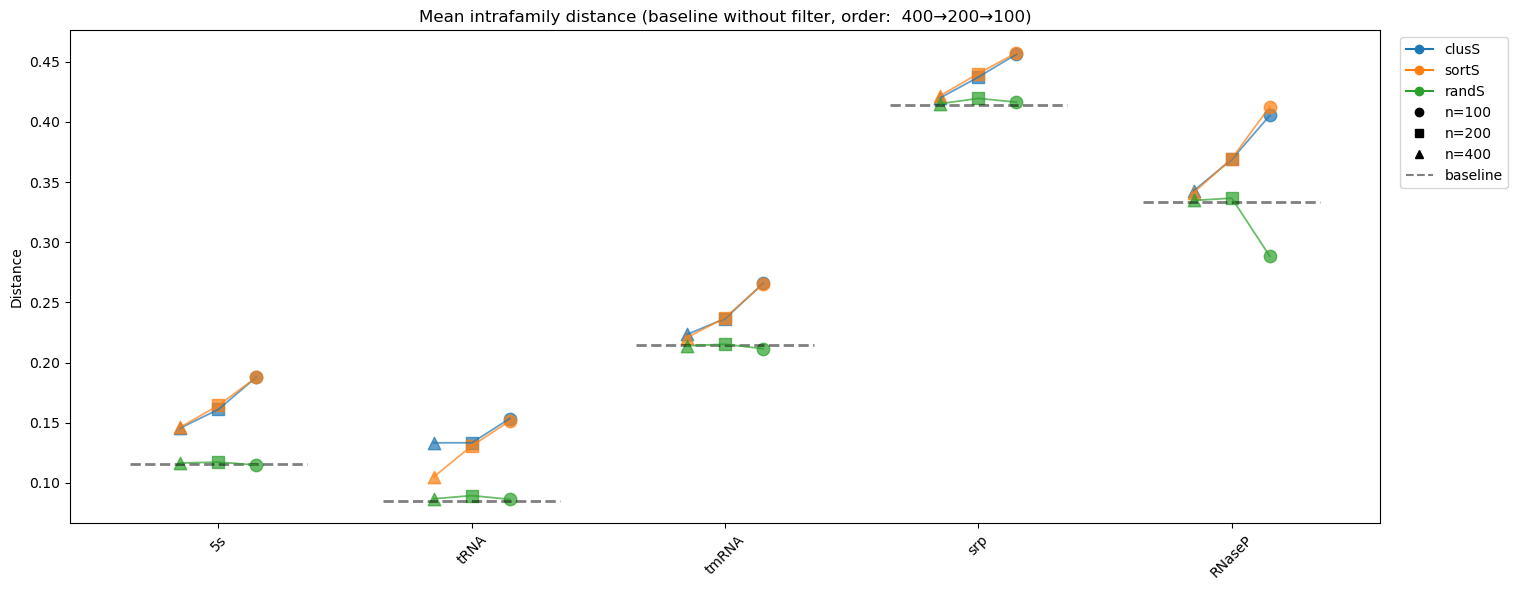

In [8]:
# Colores por ss
color_map = {ss: c for ss, c in zip(ss_list, plt.cm.tab10.colors)}

# Marcadores por n
markers = ["o", "s", "^"]
marker_map = {n: markers[i] for i, n in enumerate(n_list)}

# Offsets en X según n
offsets = {n: (+0.15 - i*0.15) for i, n in enumerate(n_list)}

def plot_diagonal_curves(diags_df, ref_diag, families_changed, ss_list, n_list, title="Mean intrafamily distance"):
    plt.figure(figsize=(14, 6))
    # === CURVAS DE SS ===
    for ss in ss_list:
        for fam_idx, fam in enumerate(families_changed):

            xs, ys = [], []

            for n in n_list:
                col = f"{ss}_{n}"
                if col not in diags_df.columns:
                    continue

                xs.append(x_base[fam_idx] + offsets[n])
                ys.append(diags_df.loc[fam, col])

                plt.scatter(
                    x_base[fam_idx] + offsets[n],
                    diags_df.loc[fam, col],
                    color=color_map[ss],
                    marker=marker_map[n],
                    s=80,
                    alpha=0.7
                )

            plt.plot(
                xs,
                ys,
                color=color_map[ss],
                alpha=0.7,
                linewidth=1.3
            )

    # === BASELINE (hlines por familia) ===
    ref_vals = ref_diag.loc[families_changed].values

    for i, val in enumerate(ref_vals):
        plt.hlines(
            y=val,
            xmin=x_base[i] - 0.35,
            xmax=x_base[i] + 0.35,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.5,
            zorder=1
        ) 

    # === ejes y estética ===
    plt.xticks(x_base, families_changed, rotation=45)
    plt.ylabel("Distance")
    plt.title(title + " (baseline without filter, order:  400→200→100)")
    plt.tight_layout()

    # Leyenda
    color_handles = [
        plt.Line2D([], [], color=color_map[ss], marker='o', linestyle='-', label=f"{ss_label_map[ss]}")
        for ss in ss_list
    ]

    marker_handles = [
        plt.Line2D([], [], color='black', marker=marker_map[n], linestyle='', label=f"n={n}")
        for n in n_list
    ]

    baseline_handle = plt.Line2D([], [], color="gray", linestyle="--", label="baseline")

    plt.legend(
        handles=color_handles + marker_handles + [baseline_handle],
        bbox_to_anchor=(1.01, 1),
        loc="upper left"
    )

    plt.grid(False)
    plt.show()

plot_diagonal_curves(diags_df, ref_diag, families_changed, ss_list, n_list)

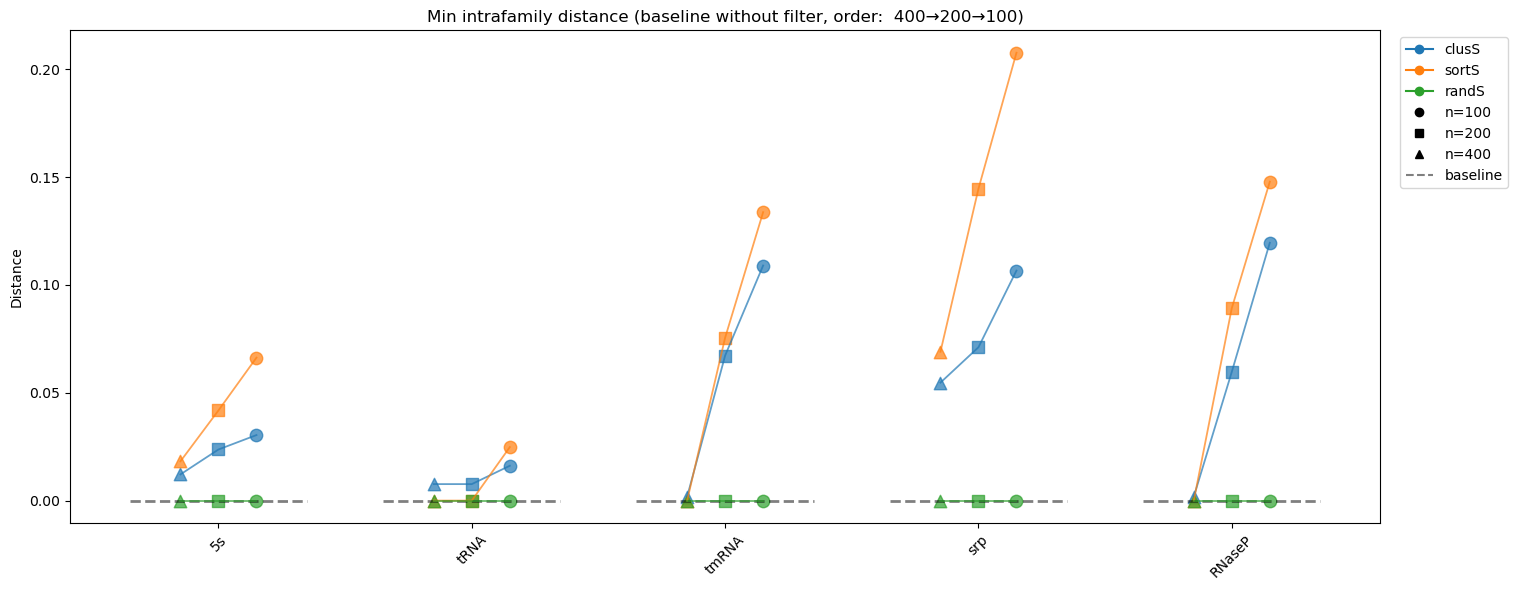

In [9]:
diags_df = pd.DataFrame(
    {k: get_diag_series(df) for k, df in min_sorted.items()}
    )
ref_diag = get_diag_series(df_sorted_min) 

plot_diagonal_curves(diags_df, ref_diag, families_changed, ss_list, n_list, title="Min intrafamily distance")

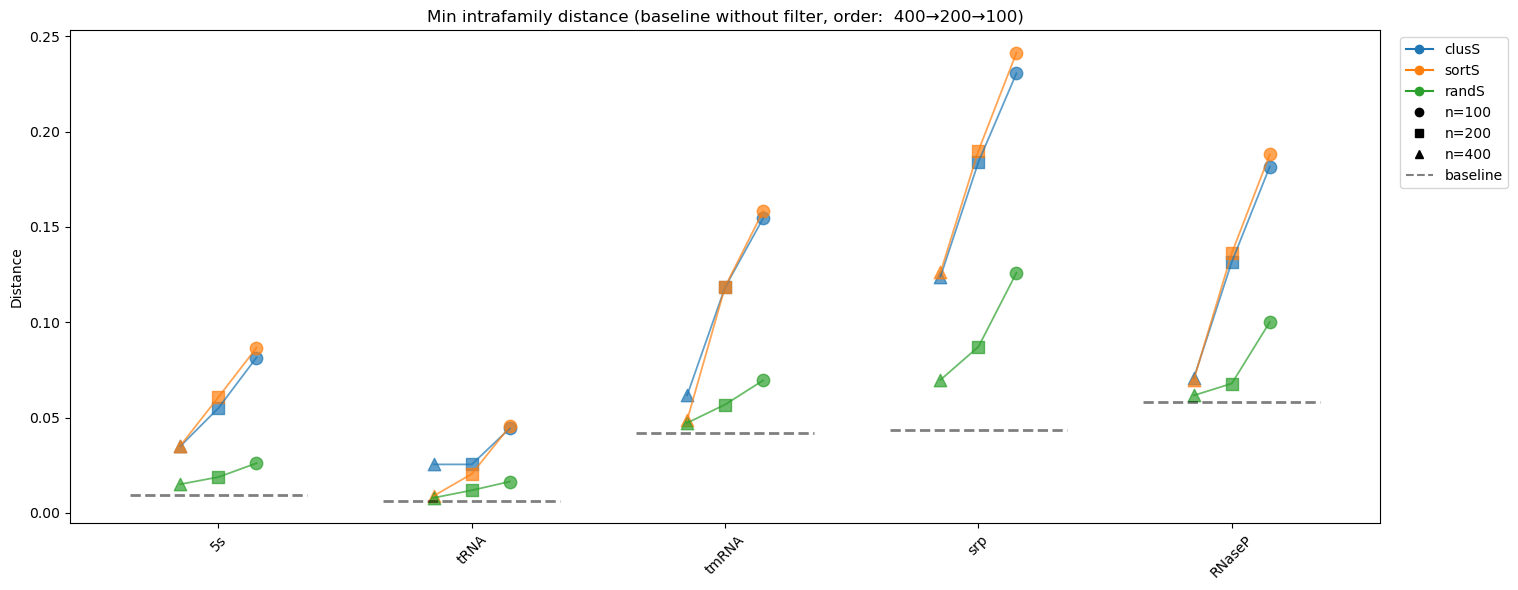

In [10]:
diags_df = pd.DataFrame(
    {k: get_diag_series(df) for k, df in avg_min_sorted.items()}
    )
ref_diag = get_diag_series(df_avg_min_sorted) 

plot_diagonal_curves(diags_df, ref_diag, families_changed, ss_list, n_list, title="Min intrafamily distance")

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
# Asumo que numpy, x_base, offsets, color_map y marker_map ya están definidos en tu entorno global

def plot_dual_diagonal_curves(
    data1,             # Tupla: (diags_df_1, ref_diag_1, title_1)
    data2,             # Tupla: (diags_df_2, ref_diag_2, title_2)
    families_changed,
    ss_list,
    n_list
):
    """
    Plotea dos gráficos lado a lado comparando métricas.
    data1 y data2 deben ser tuplas con el formato: (diags_df, ref_diag, title_string)
    """
    
    # Creamos la figura con 2 subplots (1 fila, 2 columnas)
    fig, axes = plt.subplots(1, 2, figsize=(24, 8), sharey=True) # Hacemos la figura más ancha
    
    # Iteramos sobre los ejes y los datos correspondientes
    for ax, (diags_df, ref_diag, title) in zip(axes, [data1, data2]):
        
        # === 1. CURVAS DE SS ===
        for ss in ss_list:
            for fam_idx, fam in enumerate(families_changed):
                xs, ys = [], []

                for n in n_list:
                    col = f"{ss}_{n}"
                    if col not in diags_df.columns:
                        continue
                    
                    # Usamos ax.scatter en lugar de plt.scatter
                    ax.scatter(
                        x_base[fam_idx] + offsets[n],
                        diags_df.loc[fam, col],
                        color=color_map[ss],
                        marker=marker_map[n],
                        s=80,
                        alpha=0.7
                    )
                    
                    xs.append(x_base[fam_idx] + offsets[n])
                    ys.append(diags_df.loc[fam, col])

                # Usamos ax.plot en lugar de plt.plot
                ax.plot(
                    xs,
                    ys,
                    color=color_map[ss],
                    alpha=0.7,
                    linewidth=1.3
                )

        # === 2. BASELINE (hlines por familia) ===
        ref_vals = ref_diag.loc[families_changed].values

        for i, val in enumerate(ref_vals):
            # Usamos ax.hlines
            ax.hlines(
                y=val,
                xmin=x_base[i] - 0.35,
                xmax=x_base[i] + 0.35,
                color="black",
                linestyle="--",
                linewidth=2,
                alpha=0.5,
                zorder=1
            ) 

        # === 3. Ejes y estética específica del subplot ===
        ax.set_xticks(x_base)
        ax.set_xticklabels(families_changed, rotation=45, ha='right')
        ax.set_title(title)
        ax.grid(False)

    axes[0].set_ylabel("Distance")
    # === 4. Leyenda Global (Solo la ponemos en el segundo gráfico para no ensuciar) ===
    # Creamos los handles manualmente igual que antes
    color_handles = [
        plt.Line2D([], [], color=color_map[ss], marker='o', linestyle='-', label=f"{ss}")
        for ss in ss_list
    ]

    marker_handles = [
        plt.Line2D([], [], color='black', marker=marker_map[n], linestyle='', label=f"n={n}")
        for n in n_list
    ]

    baseline_handle = plt.Line2D([], [], color="gray", linestyle="--", label="baseline")

    # Ponemos la leyenda fuera del segundo plot (axes[1])
    axes[1].legend(
        handles=color_handles + marker_handles + [baseline_handle],
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.
    )

    plt.tight_layout()
    plt.show()

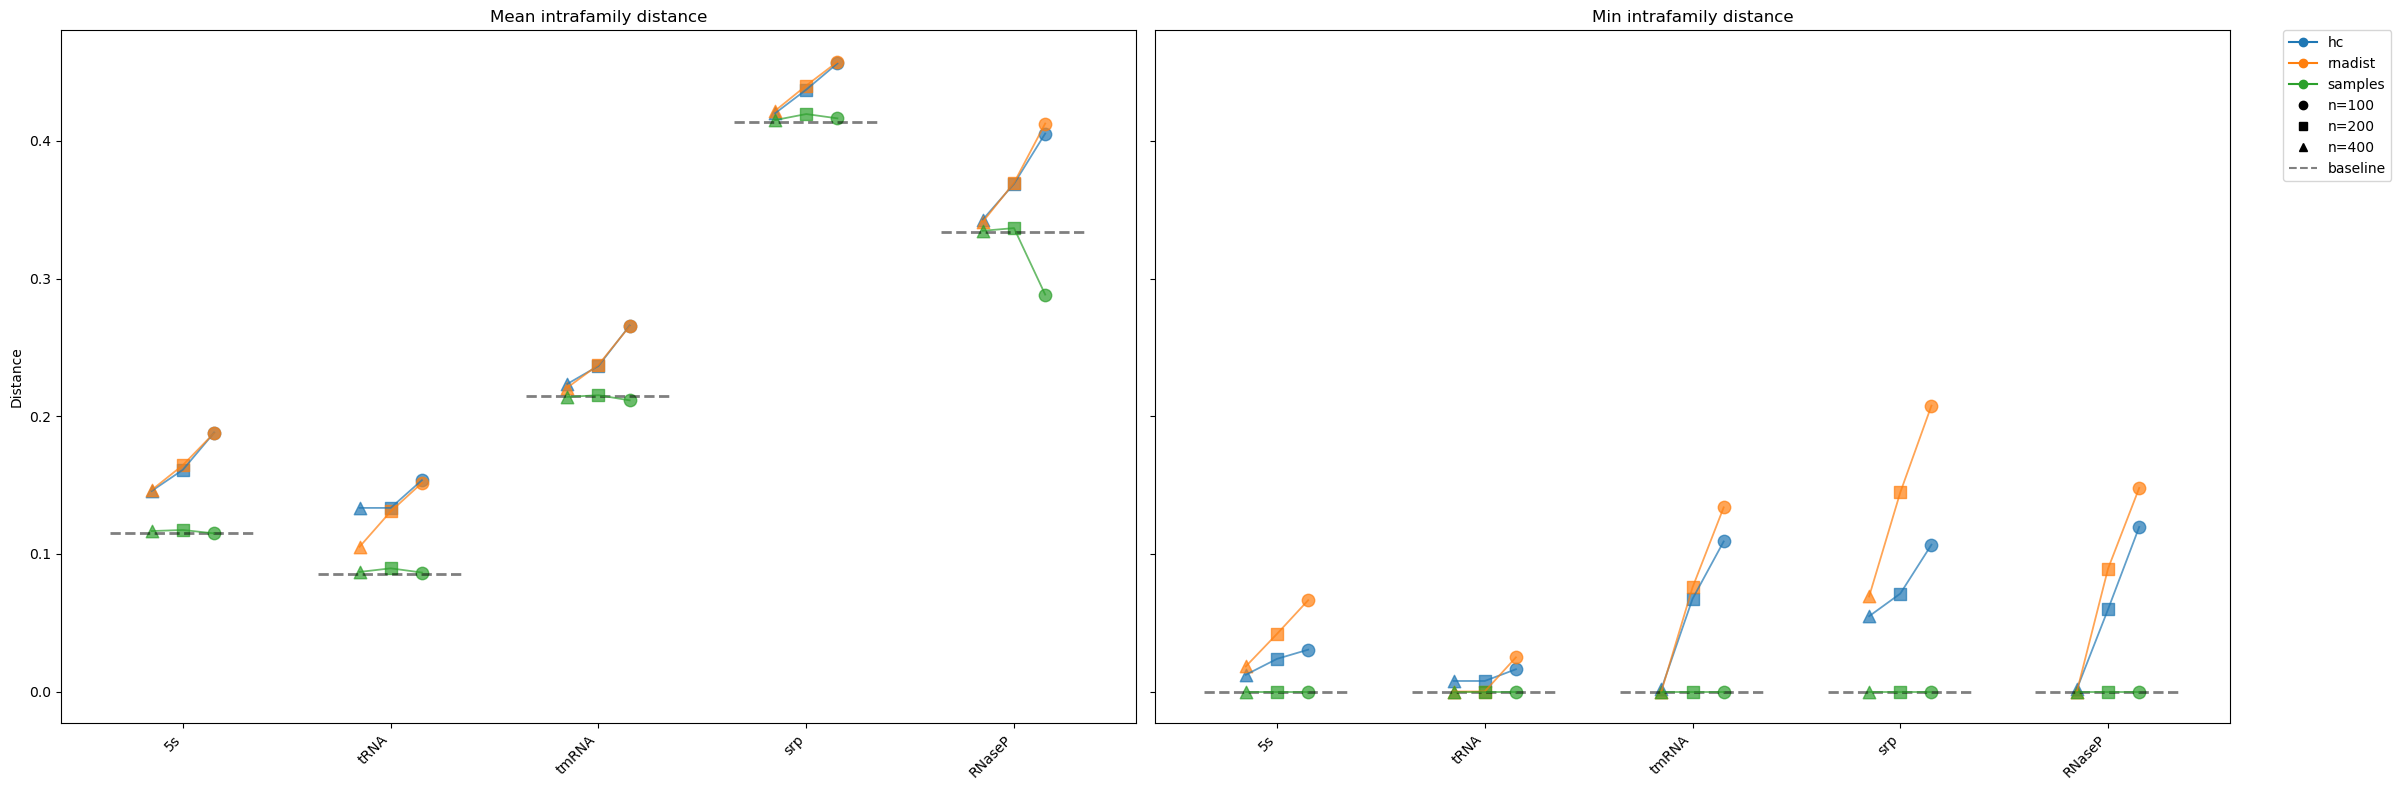

In [12]:
# --- PREPARACIÓN DE DATOS 1 ---
diags_df_1 = pd.DataFrame({k: get_diag_series(df) for k, df in mean_sorted.items()})
ref_diag_1 = get_diag_series(df_sorted_mean) 
titulo_1 = "Mean intrafamily distance"

# --- PREPARACIÓN DE DATOS 2 ---
# (Nota: en tu ejemplo usabas el mismo diags_df pero diferente ref_diag, ajusta esto según necesites)
diags_df_2 = pd.DataFrame({k: get_diag_series(df) for k, df in min_sorted.items()})
ref_diag_2 = get_diag_series(df_sorted_min) 
titulo_2 = "Min intrafamily distance"

# --- LLAMADA A LA FUNCIÓN ---
plot_dual_diagonal_curves(
    (diags_df_1, ref_diag_1, titulo_1), # Primer subplot
    (diags_df_2, ref_diag_2, titulo_2), # Segundo subplot
    families_changed,
    ss_list,
    n_list
)

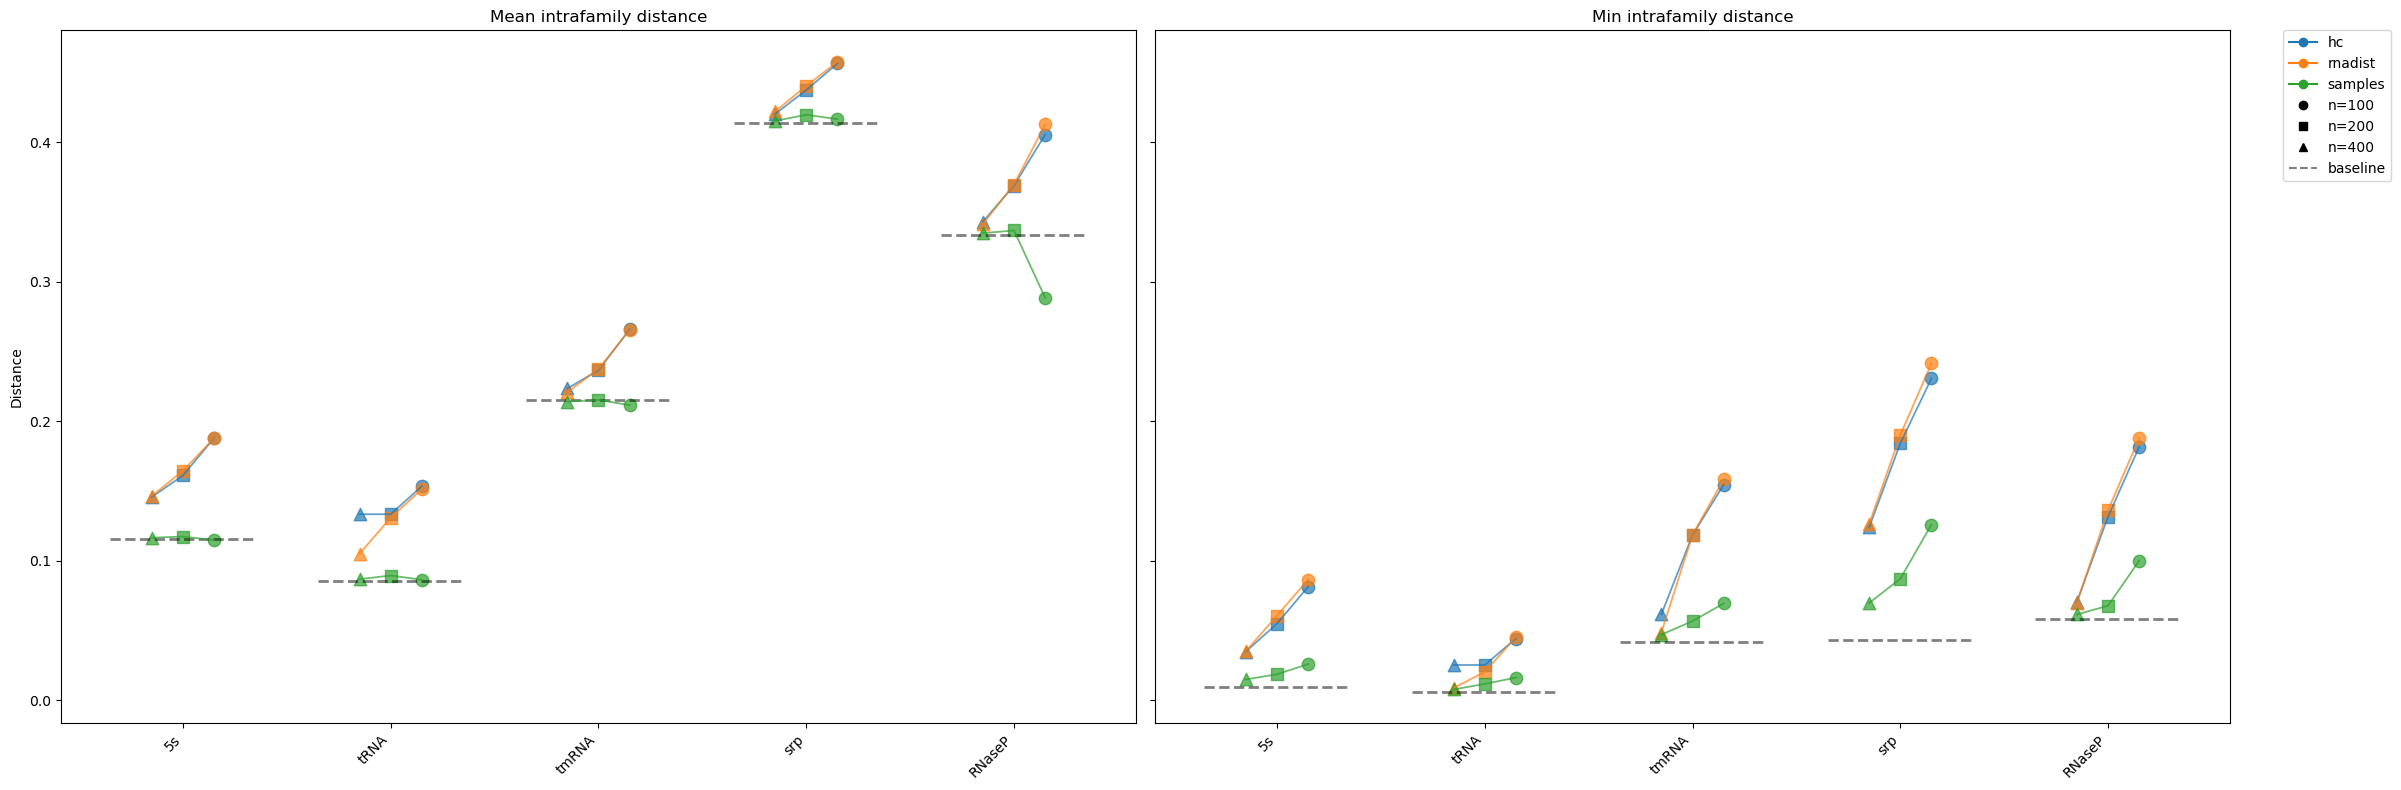

In [13]:
# --- PREPARACIÓN DE DATOS 1 ---
diags_df_1 = pd.DataFrame({k: get_diag_series(df) for k, df in mean_sorted.items()})
ref_diag_1 = get_diag_series(df_sorted_mean) 
titulo_1 = "Mean intrafamily distance"

# --- PREPARACIÓN DE DATOS 2 ---
# (Nota: en tu ejemplo usabas el mismo diags_df pero diferente ref_diag, ajusta esto según necesites)
diags_df_2 = pd.DataFrame({k: get_diag_series(df) for k, df in avg_min_sorted.items()})
ref_diag_2 = get_diag_series(df_avg_min_sorted) 
titulo_2 = "Min intrafamily distance"

# --- LLAMADA A LA FUNCIÓN ---
plot_dual_diagonal_curves(
    (diags_df_1, ref_diag_1, titulo_1), # Primer subplot
    (diags_df_2, ref_diag_2, titulo_2), # Segundo subplot
    families_changed,
    ss_list,
    n_list
)

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- ASUNCIONES ---
# Asumo que estas variables globales existen en tu entorno, como en tu ejemplo original:
# x_base, offsets, color_map, marker_map, families_changed, ss_list, n_list
# Si no, házmelo saber para integrarlas como argumentos.
# ------------------

def plot_combined_diagonal_curves(
    primary_data_tuple,   # (diags_df_mean, ref_diag_mean, "Mean")
    secondary_data_tuple, # (diags_df_min, ref_diag_min, "Min")
    families_changed,
    ss_list,
    n_list,
    title="Combined Intrafamily Distance (Mean vs Min)"
):
    fig, ax = plt.subplots(figsize=(16, 8)) # Un poco más alto y ancho

    # Empaquetamos los datos con sus estilos correspondientes para iterar
    # Estilo Principal (ej. Mean): Línea Sólida ('-'), Marcador Relleno, Baseline discontinua ('--')
    # Estilo Secundario (ej. Min): Línea Punteada (':'), Marcador Hueco, Baseline punteada (':')
    datasets = [
        {
            "data": primary_data_tuple,
            "line_style": "-",    "marker_fill": True,
            "base_style": "--",   "base_label_suffix": "(Ref)"
        },
        {
            "data": secondary_data_tuple,
            "line_style": ":",    "marker_fill": False, # Hueco
            "base_style": ":",    "base_label_suffix": "(Ref)"
        }
    ]

    # ==========================================
    # 1. BUCLE PRINCIPAL DE PLOTEO DE CURVAS
    # ==========================================
    for ds in datasets:
        diags_df, ref_diag, metric_name = ds["data"]
        ls = ds["line_style"]
        is_filled = ds["marker_fill"]

        for ss in ss_list:
            for fam_idx, fam in enumerate(families_changed):
                xs, ys = [], []
                for n in n_list:
                    col = f"{ss}_{n}"
                    if col not in diags_df.columns: continue

                    x_pos = x_base[fam_idx] + offsets[n]
                    y_val = diags_df.loc[fam, col]

                    # Configuración del Scatter (Relleno vs Hueco)
                    marker_kwargs = {
                        "marker": marker_map[n],
                        "s": 80,
                        "zorder": 3 # Puntos por encima de las líneas
                    }

                    if is_filled:
                        # Marcador estándar relleno
                        ax.scatter(x_pos, y_val, color=color_map[ss], alpha=0.7, **marker_kwargs)
                    else:
                        # Marcador hueco (facecolor='none', edgecolor=color)
                        ax.scatter(x_pos, y_val, facecolors='none', edgecolors=color_map[ss], linewidth=1.5, alpha=0.8, **marker_kwargs)

                    xs.append(x_pos)
                    ys.append(y_val)

                # Ploteo de la línea conectora (Sólida vs Punteada)
                ax.plot(xs, ys, color=color_map[ss], linestyle=ls, alpha=0.5, linewidth=1.5, zorder=2)


    # ==========================================
    # 2. PLOTEO DE BASELINES (Referencias)
    # ==========================================
    baseline_handles = []
    for ds in datasets:
        diags_df, ref_diag, metric_name = ds["data"]
        base_ls = ds["base_style"]
        label_suffix = ds["base_label_suffix"]

        ref_vals = ref_diag.loc[families_changed].values

        for i, val in enumerate(ref_vals):
            # Solo añadimos label a la primera línea horizontal de cada tipo para la leyenda
            lbl = f"{metric_name} {label_suffix}" if i == 0 else None
            
            line = ax.hlines(
                y=val, xmin=x_base[i] - 0.35, xmax=x_base[i] + 0.35,
                color="gray", linestyle=base_ls, linewidth=2, alpha=0.6, zorder=1,
                label=lbl
            )
            if i == 0: baseline_handles.append(line)


    # ==========================================
    # 3. ESTÉTICA Y LEYENDA
    # ==========================================
    ax.set_xticks(x_base)
    ax.set_xticklabels(families_changed, rotation=45)
    ax.set_ylabel("Distance")
    ax.set_title(title)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3) # Grid ayuda en gráficos complejos

    # --- Construcción de la Leyenda ---

    # a) Handles de Color (SS)
    color_handles = [plt.Line2D([], [], color=color_map[ss], marker='o', linestyle='', label=f"{ss_label_map[ss]}") for ss in ss_list]
    
    # b) Handles de Forma (N)
    marker_handles = [plt.Line2D([], [], color='black', marker=marker_map[n], linestyle='', label=f"n={n}") for n in n_list]

    # c) NUEVO: Handles de Tipo de Métrica (Visual explanation)
    # Para Mean: Línea sólida, marcador relleno
    mean_name = primary_data_tuple[2]
    metric_handle_mean = plt.Line2D([], [], color='black', marker='o', linestyle='-', fillstyle='full', markersize=8, linewidth=1.5, label=f"{mean_name} (solid)")
    
    # Para Min: Línea punteada, marcador hueco
    min_name = secondary_data_tuple[2]
    metric_handle_min = plt.Line2D([], [], color='black', marker='o', linestyle=':', fillstyle='none', markersize=8, linewidth=1.5, label=f"{min_name} (hollow)")
    
    metric_handles = [metric_handle_mean, metric_handle_min]


    # Combinar todas las leyendas
    # Ordenamos: Tipos de métrica primero (lo más importante nuevo), luego SS, luego N, luego Baselines
    full_legend = metric_handles + color_handles + marker_handles + baseline_handles

    ax.legend(
        handles=full_legend,
        bbox_to_anchor=( 0.02, 0.98), loc="upper left", borderaxespad=0.,
        title="Legend Info", fancybox=True, framealpha=0.9
    )

    plt.tight_layout()
    # Ajuste manual para que quepa bien la leyenda externa
    plt.subplots_adjust(right=0.85) 
    plt.show()

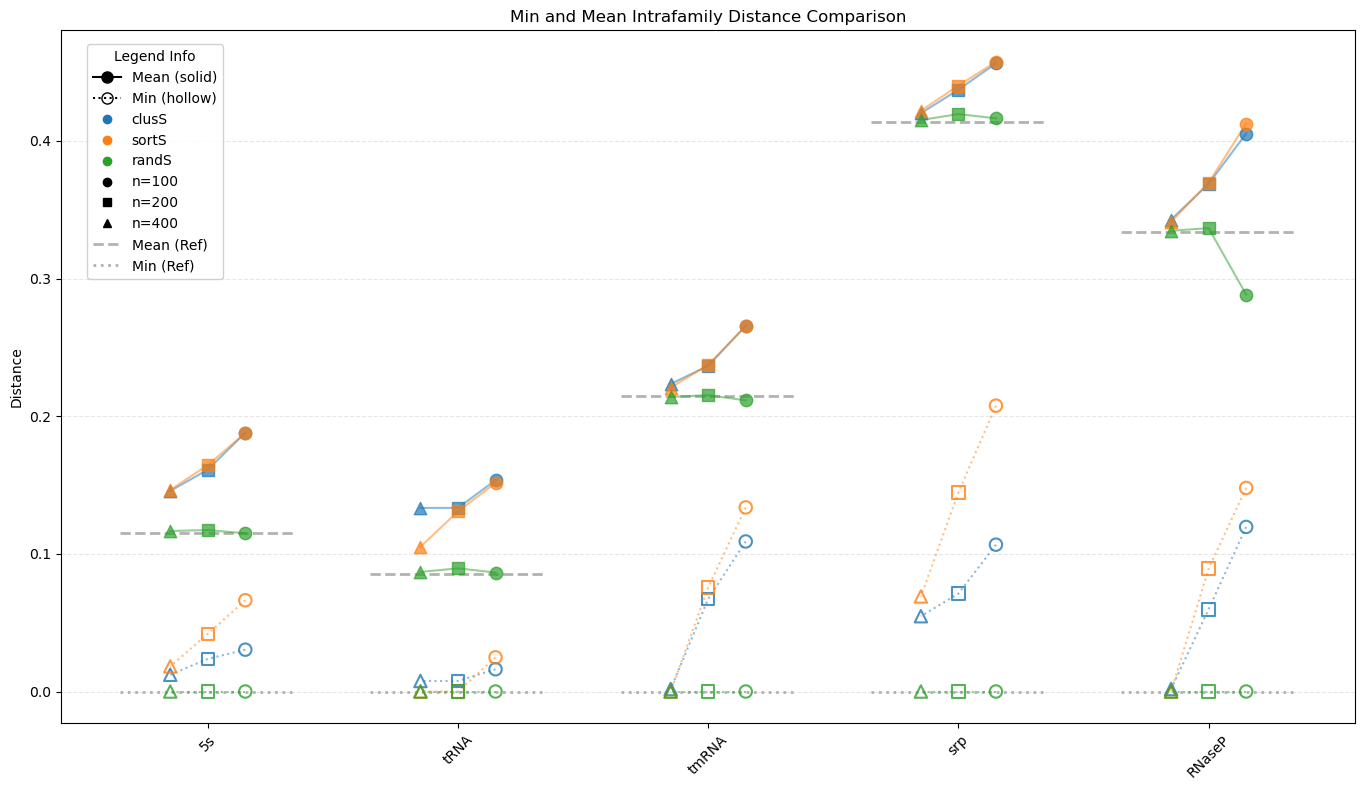

In [15]:
import pandas as pd

# --- PREPARACIÓN DE DATOS (Ejemplo basado en tus variables anteriores) ---

# 1. Datos para MEAN (Tu conjunto principal)
# Suponiendo que 'df_sorted_mean' es tu dataframe base para mean
# y 'mean_sorted' es el diccionario de dataframes filtrados para mean
diags_df_mean = pd.DataFrame({k: get_diag_series(df) for k, df in mean_sorted.items()})
ref_diag_mean = get_diag_series(df_sorted_mean)
nombre_mean = "Mean"

# 2. Datos para MIN (Tu conjunto secundario)
# Suponiendo que 'df_sorted_min' es tu dataframe base para min
# y 'min_sorted' es el diccionario de dataframes filtrados para min
diags_df_min = pd.DataFrame({k: get_diag_series(df) for k, df in min_sorted.items()})
ref_diag_min = get_diag_series(df_sorted_min)
nombre_min = "Min"


# --- LLAMADA A LA FUNCIÓN COMBINADA ---

plot_combined_diagonal_curves(
    (diags_df_mean, ref_diag_mean, nombre_mean), # Datos Principales (Sólidos)
    (diags_df_min, ref_diag_min, nombre_min),    # Datos Secundarios (Huecos/Punteados)
    families_changed,
    ss_list,
    n_list,
    title="Min and Mean Intrafamily Distance Comparison"
)

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# Asumo que x_base, offsets, color_map, marker_map, families_changed existen globalmente

def plot_combined_diagonal_curves(
    primary_data_tuple,   # (diags_df_mean, ref_diag_mean, "Mean")
    secondary_data_tuple, # (diags_df_min, ref_diag_min, "Min")
    families_changed,
    ss_list,
    n_list,
    ss_label_map=None,    # NUEVO: diccionario para nombres bonitos de ss
    title="Combined Intrafamily Distance"
):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Si no pasan mapa de etiquetas, usar el valor crudo
    if ss_label_map is None:
        ss_label_map = {ss: str(ss) for ss in ss_list}

    # Configuración de estilos
    datasets = [
        {
            "data": primary_data_tuple,
            "line_style": "-",    "marker_fill": True,
            "base_style": "--"
        },
        {
            "data": secondary_data_tuple,
            "line_style": ":",    "marker_fill": False,
            "base_style": ":"
        }
    ]

    # ==========================================
    # 1. PLOTEO DE CURVAS Y BASELINES
    # ==========================================
    for ds in datasets:
        diags_df, ref_diag, _ = ds["data"]
        ls = ds["line_style"]
        is_filled = ds["marker_fill"]
        base_ls = ds["base_style"]

        # A) Curvas
        for ss in ss_list:
            for fam_idx, fam in enumerate(families_changed):
                xs, ys = [], []
                for n in n_list:
                    col = f"{ss}_{n}"
                    if col not in diags_df.columns: continue

                    x_pos = x_base[fam_idx] + offsets[n]
                    y_val = diags_df.loc[fam, col]
                    
                    marker_kwargs = {"marker": marker_map[n], "s": 80, "zorder": 3}

                    if is_filled:
                        ax.scatter(x_pos, y_val, color=color_map[ss], alpha=0.7, **marker_kwargs)
                    else:
                        ax.scatter(x_pos, y_val, facecolors='none', edgecolors=color_map[ss], linewidth=1.5, alpha=0.8, **marker_kwargs)

                    xs.append(x_pos)
                    ys.append(y_val)

                ax.plot(xs, ys, color=color_map[ss], linestyle=ls, alpha=0.5, linewidth=1.5, zorder=2)

        # B) Baselines (Referencias horizontales)
        ref_vals = ref_diag.loc[families_changed].values
        for i, val in enumerate(ref_vals):
            ax.hlines(
                y=val, xmin=x_base[i] - 0.35, xmax=x_base[i] + 0.35,
                color="gray", linestyle=base_ls, linewidth=2, alpha=0.6, zorder=1
            )

    # ==========================================
    # 2. CONFIGURACIÓN DE EJES
    # ==========================================
    ax.set_xticks(x_base)
    ax.set_xticklabels(families_changed, rotation=45)
    ax.set_ylabel("Distance")
    # ax.set_title(title)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    # ==========================================
    # 3. LEYENDA ORDENADA
    # ==========================================
    
    mean_name = primary_data_tuple[2]
    min_name = secondary_data_tuple[2]

    # Grupo 1: Métricas (Mean / Min) y Referencias
    metrics_handles = [
        # Mean (Solid)
        Line2D([], [], color='black', marker='o', linestyle='-', fillstyle='full', 
               markersize=8, linewidth=1.5, label=f"{mean_name} (solid)"),
        # Mean Ref (Dashed)
        Line2D([], [], color='gray', linestyle='--', linewidth=2, 
               label=f"{mean_name} ref (dashed)"),
        
        # Min (Hollow)
        Line2D([], [], color='black', marker='o', linestyle=':', fillstyle='none', 
               markersize=8, linewidth=1.5, label=f"{min_name} (hollow)"),
        # Min Ref (Dotted)
        Line2D([], [], color='gray', linestyle=':', linewidth=2, 
               label=f"{min_name} ref (dotted)")
    ]

    # Grupo 2: Métodos (Colores)
    # Usamos ss_label_map aquí como pediste
    color_handles = [
        Line2D([], [], color=color_map[ss], marker='o', linestyle='', 
               label=f"{ss_label_map[ss]}") 
        for ss in ss_list
    ]
    
    # Grupo 3: Parámetro N (Formas)
    marker_handles = [
        Line2D([], [], color='black', marker=marker_map[n], linestyle='', 
               label=f"n={n}") 
        for n in n_list
    ]

    # Concatenar en el orden deseado
    full_legend = metrics_handles + color_handles + marker_handles


    ax.legend(
        handles=full_legend,
        bbox_to_anchor=( 0.5, -0.23), loc="lower center",  ncols=5, frameon=False,
    )
    plt.tight_layout()
    plt.subplots_adjust(right=0.85) 
    plt.savefig("intra_family_distance.svg", dpi=300)
    plt.savefig("intra_family_distance.png", dpi=300)
    plt.show()

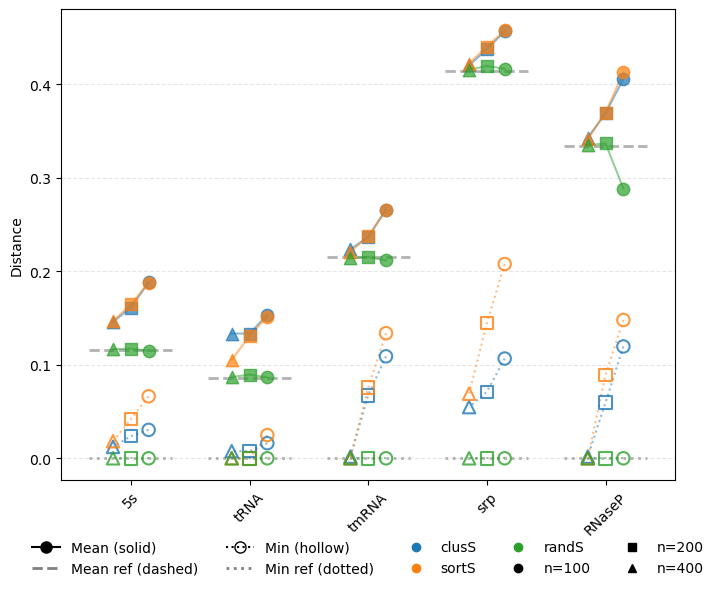

In [17]:
import pandas as pd 
 
diags_df_mean = pd.DataFrame({k: get_diag_series(df) for k, df in mean_sorted.items()})
ref_diag_mean = get_diag_series(df_sorted_mean)
nombre_mean = "Mean"
 
diags_df_min = pd.DataFrame({k: get_diag_series(df) for k, df in min_sorted.items()})
ref_diag_min = get_diag_series(df_sorted_min)
nombre_min = "Min"


# --- LLAMADA A LA FUNCIÓN COMBINADA ---

plot_combined_diagonal_curves(
    (diags_df_mean, ref_diag_mean, nombre_mean), # Datos Principales (Sólidos)
    (diags_df_min, ref_diag_min, nombre_min),    # Datos Secundarios (Huecos/Punteados)
    families_changed,
    ss_list,
    n_list,
    ss_label_map=ss_label_map,   
    title="Min and Mean Intrafamily Distance Comparison"
)